In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
import os
import sys
import json
from sklearn.metrics import root_mean_squared_error
from ase.io import read, write
import numpy as np
import time
from mace.calculators import MACECalculator
from pymatgen.io.vasp.outputs import Vasprun
from pathlib import Path
from sklearn.metrics import root_mean_squared_error
from ase.io import read, write
from sklearn.mixture import GaussianMixture
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
from pymatgen.core import Structure
from dscribe.descriptors import SOAP
from ase.build import molecule
import math
from sklearn.decomposition import PCA

/opt/anaconda3/envs/mace/lib/python3.13/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [2]:
# Figure Information
plt.style.use('default')
colors = ['#E9C5DD', '#C5A7C1', '#A18AA5', '#7E6E8A', '#5C5470', '#3B3657']
plt.rc('font', size=18)
plt.rc('axes', titlesize=22)
plt.rc('axes', labelsize=20)
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)
plt.rc('legend', fontsize=18)
plt.rc('figure', titlesize=15)
plt.rcParams['axes.linewidth'] = 3

In [3]:
class DFTInfo():
    def __init__(self, structure, forces, stress, energy, success=True):
        self.structure = structure
        self.forces = forces
        self.stress = stress
        self.energy = energy
        self.success = success
    def __str__(self):
        return str(self.structure) + str(self.forces) + str(self.energy)
    def xyz_forces(self):
        if not self.success:
            return None
        arr = []
        for site, force in zip(self.structure.sites, self.forces):
            arr.append(np.concatenate([site.coords, force]))
        return np.array(arr)
    def from_json(cls, json_path):
        try:
            with open(json_path, "r") as f:
                data = json.load(f)
            structure = Structure.from_dict(data["structure"])
            forces = np.array(data["forces"])
            stress = np.array(data["stress"])
            energy = data["energy"]
            return cls(structure, forces, stress, energy, success=True)
        except Exception as e:
            print(f"Error reading JSON {json_path}: {e}")
            return cls(None, None, None, None, success=False)

In [4]:
def get_DFT_from_directory(dir_path):
    """ Takes in directory, reads in JSON files, and outputs dictionary of (timestep, DFTInfo)
    """
    frames = {}
    for fname in sorted(os.listdir(dir_path)):
        timestep = int(fname.split(".")[1])
        frames[timestep] = DFTInfo.from_json(DFTInfo, os.path.join(dir_path, fname + '/vasp_info.json'))
    return frames

# [PBE+U Cobalt Linear Response Theory](https://www.vasp.at/wiki/index.php/Calculate_U_for_LSDA+U)

In [6]:
dV = np.array([-0.2, -0.1, 0, 0.1, 0.2])
ground_state = np.array([6.996, 6.996, 6.996, 6.996, 6.996])
NSC_response = np.array([6.924, 6.959, 6.996, 7.036, 7.08])
SC_response = np.array([6.972, 6.984, 6.996, 7.008, 7.02])
SC_slope, SC_intercept = np.polyfit(dV, SC_response, 1)
NSC_slope, NSC_intercept = np.polyfit(dV, NSC_response, 1)
U = 1/(SC_slope)-1/(NSC_slope)
print(U)

5.762639245929902


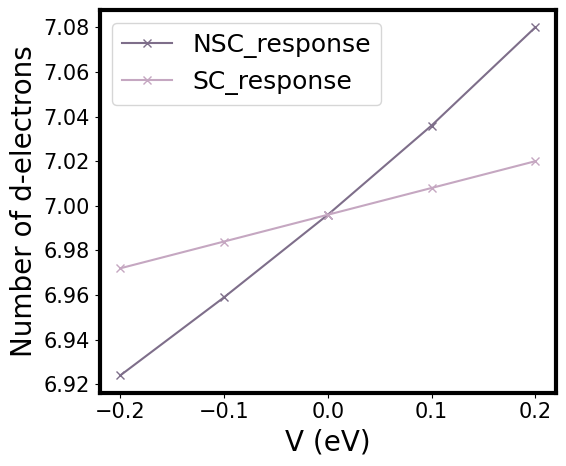

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(dV, NSC_response, '-x', label='NSC_response', color=colors[3])
ax.plot(dV, SC_response, '-x', label='SC_response', color=colors[1])
ax.set_xlabel("V (eV)")
ax.set_ylabel("Number of d-electrons")
ax.legend()
fig.tight_layout()
fig.savefig("./supplemental_figs/SI_linearResponse.svg")

# Periodic Fine-tuning Results

In [8]:
U_Train_DFT = get_DFT_from_directory("../data/ChClCA_Finetuning/Periodic/Model:U/dft")
FT1_Train_DFT = get_DFT_from_directory("../data/ChClCA_Finetuning/Periodic/Model:FT1/dft")
FT2_Train_DFT = get_DFT_from_directory("../data/ChClCA_Finetuning/Periodic/Model:FT2/dft")
FT3_Train_DFT = get_DFT_from_directory("../data/ChClCA_Finetuning/Periodic/Model:FT3/dft")
FT4_Train_DFT = get_DFT_from_directory("../data/ChClCA_Finetuning/Periodic/Model:FT4/dft")
FT5_Train_DFT = get_DFT_from_directory("../data/ChClCA_Finetuning/Periodic/Model:FT5/dft")
U_Train_MD = pd.read_csv("../data/ChClCA_Finetuning/Periodic/Model:U/md/run_info.txt", sep = '\t')
FT1_Train_MD = pd.read_csv("../data/ChClCA_Finetuning/Periodic/Model:FT1/md/run_info.txt", sep = '\t')
FT2_Train_MD = pd.read_csv("../data/ChClCA_Finetuning/Periodic/Model:FT2/md/run_info.txt", sep = '\t')
FT3_Train_MD = pd.read_csv("../data/ChClCA_Finetuning/Periodic/Model:FT3/md/run_info.txt", sep = '\t')
FT4_Train_MD = pd.read_csv("../data/ChClCA_Finetuning/Periodic/Model:FT4/md/run_info.txt", sep = '\t')
FT5_Train_MD = pd.read_csv("../data/ChClCA_Finetuning/Periodic/Model:FT5/md/run_info.txt", sep = '\t')
training_DFT = [U_Train_DFT, FT1_Train_DFT, FT2_Train_DFT, FT3_Train_DFT, FT4_Train_DFT, FT5_Train_DFT]
training_MD = [U_Train_MD, FT1_Train_MD, FT2_Train_MD, FT3_Train_MD, FT4_Train_MD, FT5_Train_MD]

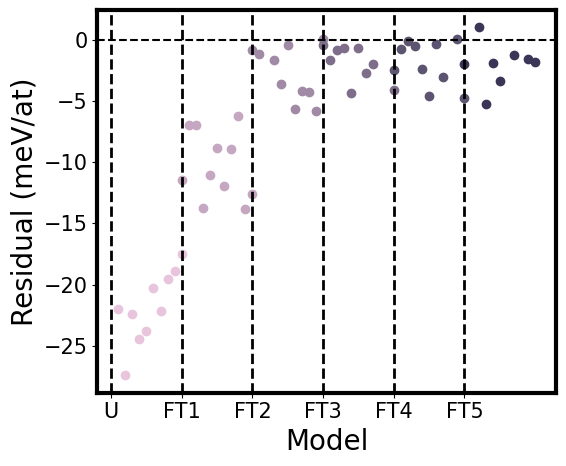

In [9]:
fig, ax = plt.subplots(figsize = (6, 5))
for idx, trajectory in enumerate(zip(training_DFT, training_MD)):
    diffs = {}
    for timestep in trajectory[0].keys():
        diff = (trajectory[1].iloc[timestep]['PotEng'] - trajectory[0][timestep].energy) * 1000 / 197
        diffs[timestep/1000+idx] = diff
    ax.plot(diffs.keys(), diffs.values(), 'o', color = colors[idx])
ax.axhline(y=0, linestyle='--', color='black')
ax.axvline(x=1, linestyle='--', linewidth=2, color='black')
# ranges = [(1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7)]
# for (start, end), color in zip(ranges, colors):
#     ax.axvspan(start, end, alpha=0.3, color=color)
ax.axvline(x=2, linestyle='--', linewidth=2, color='black')
ax.axvline(x=3, linestyle='--', linewidth=2, color='black')
ax.axvline(x=4, linestyle='--', linewidth=2, color='black')
ax.axvline(x=5, linestyle='--', linewidth=2, color='black')
ax.axvline(x=6, linestyle='--', linewidth=2, color='black')
# ax.axvline(x=7, linestyle='--', linewidth=2, color='black')
ax.set_xticks(np.arange(1,7), ['U', 'FT1', 'FT2', 'FT3', 'FT4', 'FT5'])
ax.set_xlabel("Model")
ax.set_ylabel("Residual (meV/at)")
fig.tight_layout()
fig.savefig("./supplemental_figs/SI_trainingEvaluation.svg")

# Nonperiodic Analysis

In [10]:
test_set = get_DFT_from_directory("../data/ChClCA_Evaluations/Independent_Test_Set")
nonperiodic_dataset = read("../data/ChClCA_Finetuning/Nonperiodic/Finetuned_Models/NP-50pts/np50pt_dataset_raw.xyz", ":")
periodic_dataset = read("../data/ChClCA_Finetuning/Periodic/Model:FT5/model/ft4_data_raw.xyz", ":")
naive_dataset = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-50pts/ft_dataset_raw.xyz", ":")
np50_calc = MACECalculator("../data/ChClCA_Finetuning/Nonperiodic/Finetuned_Models/NP-50pts/nonperiodic_50.model")
ft5_calc = MACECalculator("../data/ChClCA_Finetuning/Periodic/Model:FT5/model/ft5.model")
n50_calc = MACECalculator("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-50pts/50pts.model")

Using head Default out of ['pt_head', 'Default']
No dtype selected, switching to float64 to match model dtype.
Using head Default out of ['pt_head', 'Default']
No dtype selected, switching to float64 to match model dtype.
Using head Default out of ['pt_head', 'Default']
No dtype selected, switching to float64 to match model dtype.


/opt/anaconda3/envs/mace/lib/python3.13/site-packages/mace/calculators/mace.py:166: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/opt/anaconda3/envs/mace/lib/python3.13/site-packages/mace/calculators/mace.py:166: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/opt/anaconda3/envs/mace/lib/python3.13/site-packages/mace/calculators/mace.py:166: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


In [11]:
test_energies = []
test_energies = [test_set[s].energy * 1000 / 197 for s in test_set]
nonperiodic_energies = [s.get_potential_energy() * 1000 / 197 for s in nonperiodic_dataset]
periodic_energies = [s.get_potential_energy() * 1000 / 197 for s in periodic_dataset]
naive_energies = [s.get_potential_energy() * 1000 / 197 for s in naive_dataset]
test_energies_dict = {}
for key in test_set.keys():
    dftinfo = test_set.get(key)
    energy = dftinfo.energy * 1000 / 197
    test_energies_dict[key] = energy

In [12]:
ind_set = {}
root_folder = '../data/ChClCA_Evaluations/Independent_Test_Set'
for subdir, dirs, files in os.walk(root_folder):
    for file in files:
        if file == 'POSCAR':
            filepath = os.path.join(subdir, file)
            atom = read(filepath)
            match = re.search(r'eval\.(\d+)$', subdir)
            if(match):
                num = int(match.group(1))
                ind_set[num] = atom

In [13]:
periodic_energies_dict = {}
nonperiodic_energies_dict = {}
naive_energies_dict = {}
for key in ind_set.keys():
    atom = ind_set.get(key)
    atom.calc = ft5_calc
    periodic_energies_dict[key] = atom.get_potential_energy()*1000/197
    atom.calc = np50_calc
    nonperiodic_energies_dict[key] = atom.get_potential_energy()*1000/197
    atom.calc = n50_calc
    naive_energies_dict[key] = atom.get_potential_energy()*1000/197

In [14]:
periodic_residuals_dict = {}
nonperiodic_residuals_dict = {}
naive_residuals_dict = {}
for key in test_energies_dict.keys():
    periodic_residuals_dict[key] = [periodic_energies_dict.get(key)-test_energies_dict.get(key), test_energies_dict.get(key)]
    nonperiodic_residuals_dict[key] = [nonperiodic_energies_dict.get(key)-test_energies_dict.get(key), test_energies_dict.get(key)]
    naive_residuals_dict[key] = [naive_energies_dict.get(key)-test_energies_dict.get(key), test_energies_dict.get(key)]


In [15]:
def compute_binned_residuals(residual_dict, bin_edges):
    """
    Compute average residuals per bin from a residual dictionary.
    Fill gaps with NaN.
    """
    energies = np.array([v[1] for v in residual_dict.values()])
    residuals = np.array([v[0] for v in residual_dict.values()])
    bin_indices = np.digitize(energies, bin_edges)
    
    bin_sums = {}
    bin_counts = {}
    bin_sq_sums = {}
    for i, bin_idx in enumerate(bin_indices):
        if bin_idx not in bin_sums:
            bin_sums[bin_idx] = 0
            bin_counts[bin_idx] = 0
            bin_sq_sums[bin_idx] = 0.0
        bin_sums[bin_idx] += residuals[i]
        bin_counts[bin_idx] += 1
        bin_sq_sums[bin_idx] += residuals[i]**2

    bin_avg_residual = {bin_idx: bin_sums[bin_idx]/bin_counts[bin_idx] 
                        for bin_idx in bin_sums}
    bin_std_residual = {
        b: np.sqrt((bin_sq_sums[b] / bin_counts[b]) -(bin_avg_residual[b] ** 2))
        for b in bin_sums
    }

    all_bins = np.arange(min(bin_avg_residual.keys()), max(bin_avg_residual.keys()) + 1)
    avg_residual_array = np.array([bin_avg_residual.get(b, np.nan) for b in all_bins])
    std_array = np.array([bin_std_residual.get(b, np.nan) for b in all_bins])
    
    return all_bins, avg_residual_array, std_array


datasets = {
    'Test': test_energies,
    'Naive': naive_energies,
    'Periodic': periodic_energies,
    'Nonperiodic': nonperiodic_energies
}
all_energies = np.concatenate(list(datasets.values()))
min_edge = math.floor(all_energies.min())
max_edge = math.ceil(all_energies.max())
bin_edges = np.arange(min_edge, max_edge + 2, 2)


periodic_bins, periodic_avg_residual, periodic_std = compute_binned_residuals(periodic_residuals_dict, bin_edges)
nonperiodic_bins, nonperiodic_avg_residual, nonperiodic_std = compute_binned_residuals(nonperiodic_residuals_dict, bin_edges)
naive_bins, naive_avg_residual, naive_std = compute_binned_residuals(naive_residuals_dict, bin_edges)

/var/folders/b3/hx8307zs7kl5xs560yl1xw4m0000gn/T/ipykernel_1181/2029620179.py:80: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


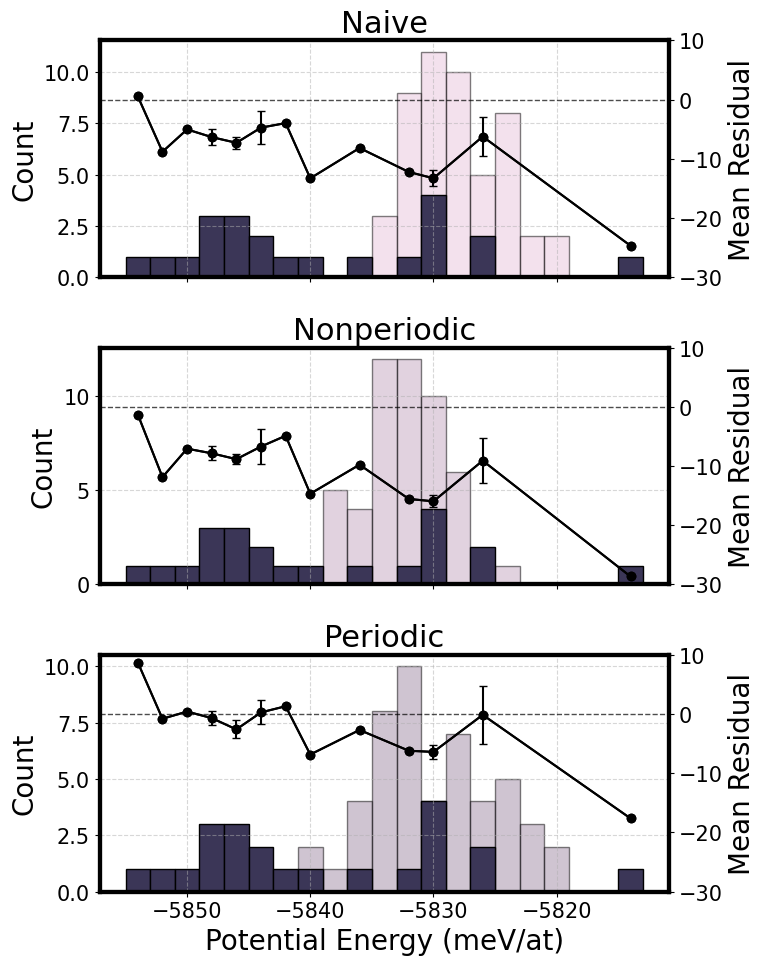

In [16]:

datasets = {
    'Test': test_energies,
    'Naive': naive_energies,
    'Periodic': periodic_energies,
    'Nonperiodic': nonperiodic_energies
}
all_energies = np.concatenate(list(datasets.values()))
min_edge = math.floor(all_energies.min())
max_edge = math.ceil(all_energies.max())
bin_edges = np.arange(min_edge, max_edge + 2, 2)
datasets = {
    'Naive': naive_energies,
    'Nonperiodic': nonperiodic_energies,
    'Periodic': periodic_energies
}
fig, axes = plt.subplots(len(datasets), 1, figsize=(8, 10), sharex=True)

for i, (ax, (label, data)) in enumerate(zip(axes, datasets.items())):
    ax.hist(data, bins=bin_edges, color=colors[i], edgecolor='black', alpha=0.5)
    ax.hist(test_energies, bins=bin_edges, color=colors[5], edgecolor='black', alpha=1)
    ax.set_title(label)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylabel("Count")
    if i == 0:
        ax2 = ax.twinx()
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        valid = ~np.isnan(naive_avg_residual)
        ax2.plot(bin_centers[valid], naive_avg_residual[valid], color='black', marker='o', linestyle='-')
        ax2.errorbar(
            bin_centers[valid],
            naive_avg_residual[valid],
            yerr=naive_std[valid],
            marker='o',
            linestyle='-',
            color='black',
            capsize=3
        )
        ax2.set_ylabel("Mean Residual")
        ax2.tick_params(axis='y')
        ax2.axhline(0, linewidth=1, linestyle='--', alpha=0.7, color='black')
        ax2.set_ylim(-30, 10)
    if i == 2:
        ax2 = ax.twinx()
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        valid = ~np.isnan(periodic_avg_residual)
        ax2.plot(bin_centers[valid], periodic_avg_residual[valid], color='black', marker='o', linestyle='-')
        ax2.errorbar(
            bin_centers[valid],
            periodic_avg_residual[valid],
            yerr=periodic_std[valid],
            marker='o',
            linestyle='-',
            color='black',
            capsize=3
        )
        ax2.set_ylabel("Mean Residual")
        ax2.tick_params(axis='y')
        ax2.axhline(0, linewidth=1, linestyle='--', alpha=0.7, color='black')
        ax2.set_ylim(-30, 10)
    if i == 1:
        ax2 = ax.twinx()
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        ax2.errorbar(
            bin_centers[valid],
            nonperiodic_avg_residual[valid],
            yerr=nonperiodic_std[valid],
            marker='o',
            linestyle='-',
            color='black',
            capsize=3
        )
        valid = ~np.isnan(nonperiodic_avg_residual)
        ax2.plot(bin_centers[valid], nonperiodic_avg_residual[valid], color='black', marker='o', linestyle='-')
        ax2.set_ylabel("Mean Residual")
        ax2.tick_params(axis='y')
        ax2.axhline(0, linewidth=1, linestyle='--', alpha=0.7, color='black')
        ax2.set_ylim([-30,10])
ax.set_xlabel("Potential Energy (meV/at)")
fig.tight_layout()
fig.show()
fig.savefig("supplemental_figs/SI_indEvalSet.svg")


In [17]:
U_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Periodic/U/dft")
FT1_Eval_DFT =  get_DFT_from_directory("../data/ChClCA_Evaluations/Periodic/FT1/dft")
FT2_Eval_DFT =  get_DFT_from_directory("../data/ChClCA_Evaluations/Periodic/FT2/dft")
FT3_Eval_DFT =  get_DFT_from_directory("../data/ChClCA_Evaluations/Periodic/FT3/dft")
FT4_Eval_DFT =  get_DFT_from_directory("../data/ChClCA_Evaluations/Periodic/FT4/dft")
FT5_Eval_DFT =  get_DFT_from_directory("../data/ChClCA_Evaluations/Periodic/FT5/dft")
N_10pts_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Naive/N-10pts/dft")
N_21pts_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Naive/N-21pts/dft")
N_31pts_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Naive/N-31pts/dft")
N_40pts_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Naive/N-40pts/dft")
N_50pts_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Naive/N-50pts/dft")
NP_10pts_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Nonperiodic/NP-10pts/dft")
NP_21pts_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Nonperiodic/NP-21pts/dft")
NP_31pts_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Nonperiodic/NP-31pts/dft")
NP_40pts_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Nonperiodic/NP-40pts/dft")
NP_50pts_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Nonperiodic/NP-50pts/dft")
U_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Periodic/U/md/run_info.txt", sep='\t')
FT1_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Periodic/FT1/md/run_info.txt", sep='\t')
FT2_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Periodic/FT2/md/run_info.txt", sep='\t')
FT3_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Periodic/FT3/md/run_info.txt", sep='\t')
FT4_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Periodic/FT4/md/run_info.txt", sep='\t')
FT5_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Periodic/FT5/md/run_info.txt", sep='\t')
N_10pts_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Naive/N-10pts/md/run_info.txt", sep='\t')
N_21pts_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Naive/N-21pts/md/run_info.txt", sep='\t')
N_31pts_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Naive/N-31pts/md/run_info.txt", sep='\t')
N_40pts_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Naive/N-40pts/md/run_info.txt", sep='\t')
N_50pts_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Naive/N-50pts/md/run_info.txt", sep='\t')
NP_10pts_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Nonperiodic/NP-10pts/md/run_info.txt", sep='\t')
NP_21pts_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Nonperiodic/NP-21pts/md/run_info.txt", sep='\t')
NP_31pts_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Nonperiodic/NP-31pts/md/run_info.txt", sep='\t')
NP_40pts_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Nonperiodic/NP-40pts/md/run_info.txt", sep='\t')
NP_50pts_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Nonperiodic/NP-50pts/md/run_info.txt", sep='\t')
Nonperiodic_Eval_PotEng = [U_Eval_MD, NP_10pts_Eval_MD, NP_21pts_Eval_MD, NP_31pts_Eval_MD, NP_40pts_Eval_MD, NP_50pts_Eval_MD]
Nonperiodic_Eval_DFT = [U_Eval_DFT, NP_10pts_Eval_DFT, NP_21pts_Eval_DFT, NP_31pts_Eval_DFT, NP_40pts_Eval_DFT, NP_50pts_Eval_DFT]
Naive_Eval_DFT = [U_Eval_DFT, N_10pts_Eval_DFT, N_21pts_Eval_DFT, N_31pts_Eval_DFT, N_40pts_Eval_DFT, N_50pts_Eval_DFT]
Naive_Eval_MD = [U_Eval_MD, N_10pts_Eval_MD, N_21pts_Eval_MD, N_31pts_Eval_MD, N_40pts_Eval_MD, N_50pts_Eval_MD]
Periodic_Eval_DFT = [U_Eval_DFT, FT1_Eval_DFT, FT2_Eval_DFT, FT3_Eval_DFT, FT4_Eval_DFT, FT5_Eval_DFT]
Periodic_Eval_MD = [U_Eval_MD, FT1_Eval_MD, FT2_Eval_MD, FT3_Eval_MD, FT4_Eval_MD, FT5_Eval_MD]

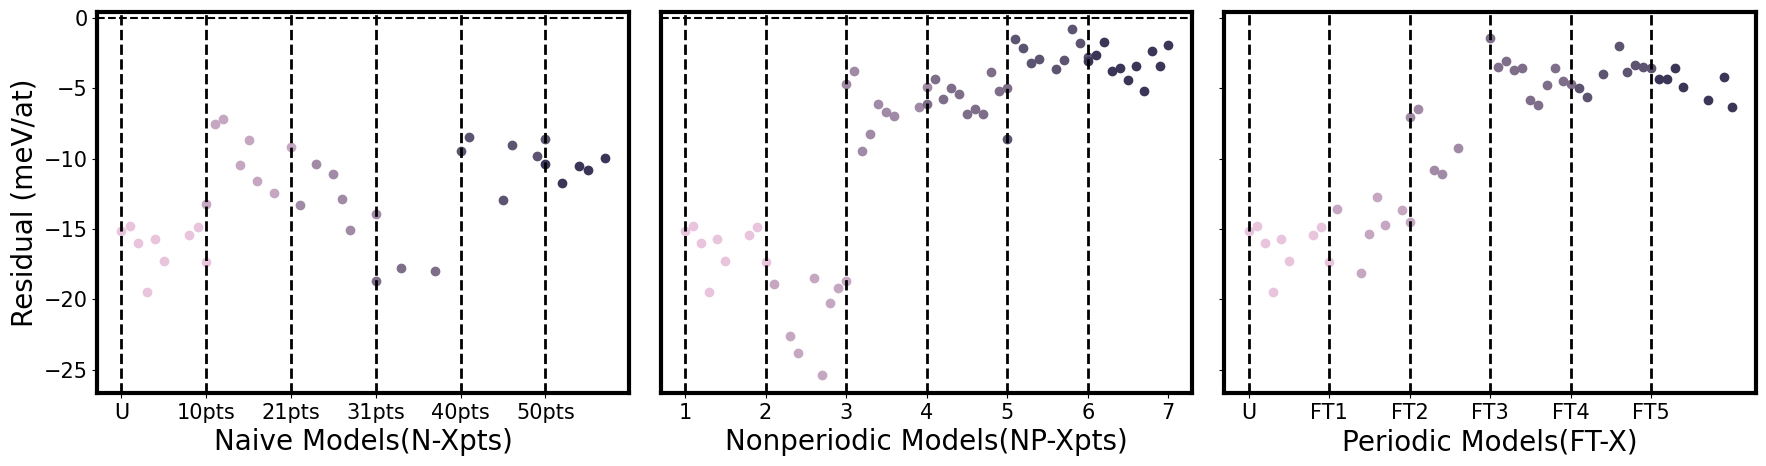

In [18]:
fig, ax = plt.subplots(1, 3, figsize = (18, 5), sharey=True)
# Left plot, Naive
for idx, trajectory in enumerate(zip(Naive_Eval_DFT, Naive_Eval_MD)):
    diffs = {}
    for timestep in trajectory[0].keys():
        diff = (trajectory[1].iloc[timestep]['PotEng'] - trajectory[0][timestep].energy) * 1000 / 197
        diffs[timestep/1000+idx] = diff
    ax[0].plot(diffs.keys(), diffs.values(), 'o', color = colors[idx])
# Middle plot, Nonperiodic

for idx, trajectory in enumerate(zip(Nonperiodic_Eval_DFT, Nonperiodic_Eval_PotEng)):
    diffs = {}
    for timestep in trajectory[0].keys():
        diff = (trajectory[1].iloc[timestep]['PotEng'] - trajectory[0][timestep].energy) * 1000 / 197
        diffs[timestep/1000+idx] = diff
    ax[1].plot(diffs.keys(), diffs.values(), 'o', color = colors[idx])
# Right plot, Periodic
for idx, trajectory in enumerate(zip(Periodic_Eval_DFT, Periodic_Eval_MD)):
    diffs = {}
    for timestep in trajectory[0].keys():
        diff = (trajectory[1].iloc[timestep]['PotEng'] - trajectory[0][timestep].energy) * 1000 / 197
        diffs[timestep/1000+idx] = diff
    ax[2].plot(diffs.keys(), diffs.values(), 'o', color = colors[idx])
ax[2].set_xticks(np.arange(1,7), ['U', 'FT1', 'FT2', 'FT3', 'FT4', 'FT5'])
# ax[1].set_xticks(np.arange(1,7), ['U', '10pts', '21pts', '31pts', '40pts', '50pts'])
ax[0].set_xticks(np.arange(1,7), ['U', '10pts', '21pts', '31pts', '40pts', '50pts'])
ax[0].axhline(y=0, linestyle='--', color='black')
ax[1].axhline(y=0, linestyle='--', color='black')
# ax[2].axhline(y=0, linestyle='--', color='black')
ax[0].axvline(x=1, linestyle='--', linewidth=2, color='black')
ax[0].axvline(x=2, linestyle='--', linewidth=2, color='black')
ax[0].axvline(x=3, linestyle='--', linewidth=2, color='black')
ax[0].axvline(x=4, linestyle='--', linewidth=2, color='black')
ax[0].axvline(x=5, linestyle='--', linewidth=2, color='black')
ax[0].axvline(x=6, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=1, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=2, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=3, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=4, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=5, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=6, linestyle='--', linewidth=2, color='black')
ax[2].axvline(x=1, linestyle='--', linewidth=2, color='black')
ax[2].axvline(x=2, linestyle='--', linewidth=2, color='black')
ax[2].axvline(x=3, linestyle='--', linewidth=2, color='black')
ax[2].axvline(x=4, linestyle='--', linewidth=2, color='black')
ax[2].axvline(x=5, linestyle='--', linewidth=2, color='black')
ax[2].axvline(x=6, linestyle='--', linewidth=2, color='black')
ax[1].tick_params(axis='y', which='both', labelcolor=(0,0,0,0))
ax[1].tick_params(axis='y', which='both', color=(0,0,0,0))
ax[1].set_xlabel("Nonperiodic Models(NP-Xpts)")
ax[0].set_xlabel("Naive Models(N-Xpts)")
ax[2].set_xlabel("Periodic Models(FT-X)")
ax[0].set_ylabel("Residual (meV/at)")
fig.tight_layout()
fig.savefig("./supplemental_figs/SI_modelEvaluationsNonperiodic.svg")

# PCA/Datasets

In [19]:
naive_set = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-50pts/ft_dataset_raw.xyz", index=':')
ft_set = read("../data/ChClCA_Finetuning/Periodic/Model:FT5/model/ft4_data_raw.xyz", index=':')
np_set = read("../data/ChClCA_Finetuning/Nonperiodic/Finetuned_Models/NP-50pts/np50pt_dataset_raw.xyz", index=':')
all_data = naive_set + ft_set + np_set
species = set()
for atoms in all_data:
    species.update(atoms.get_chemical_symbols())
species = list(species)
soap = SOAP(
    species=species,
    r_cut=5,
    n_max=8,
    l_max=6,
    sigma=0.375,
    periodic=True,
    sparse=False
)

In [20]:
# Generate SOAP
naive_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in naive_set]
ft_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in ft_set]
np_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in np_set]
# Convert to numpy arrays and flatten 
X_naive = np.array(naive_desc).reshape(-1, naive_desc[0].shape[-1])
X_ft = np.array(ft_desc).reshape(-1, ft_desc[0].shape[-1])
X_np = np.array(np_desc).reshape(-1, np_desc[0].shape[-1])

X_all = np.vstack([X_naive, X_ft, X_np])
# Fit PCA on combined data
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_all)
X_naive_pca = X_pca[:len(X_naive)]
X_ft_pca = X_pca[len(X_naive):len(X_naive)+len(X_ft)]
X_np_pca = X_pca[len(X_naive)+len(X_ft):]
explained_variance = pca.explained_variance_ratio_
print("Variance captured by each PC:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")

# Cumulative variance
cumulative_variance = explained_variance.cumsum()
print("\nCumulative variance:")
for i, cum_var in enumerate(cumulative_variance):
    print(f"PC1 to PC{i+1}: {cum_var:.4f} ({cum_var*100:.2f}%)")


Variance captured by each PC:
PC1: 0.2318 (23.18%)
PC2: 0.1908 (19.08%)
PC3: 0.1108 (11.08%)
PC4: 0.0861 (8.61%)
PC5: 0.0683 (6.83%)

Cumulative variance:
PC1 to PC1: 0.2318 (23.18%)
PC1 to PC2: 0.4227 (42.27%)
PC1 to PC3: 0.5335 (53.35%)
PC1 to PC4: 0.6196 (61.96%)
PC1 to PC5: 0.6879 (68.79%)


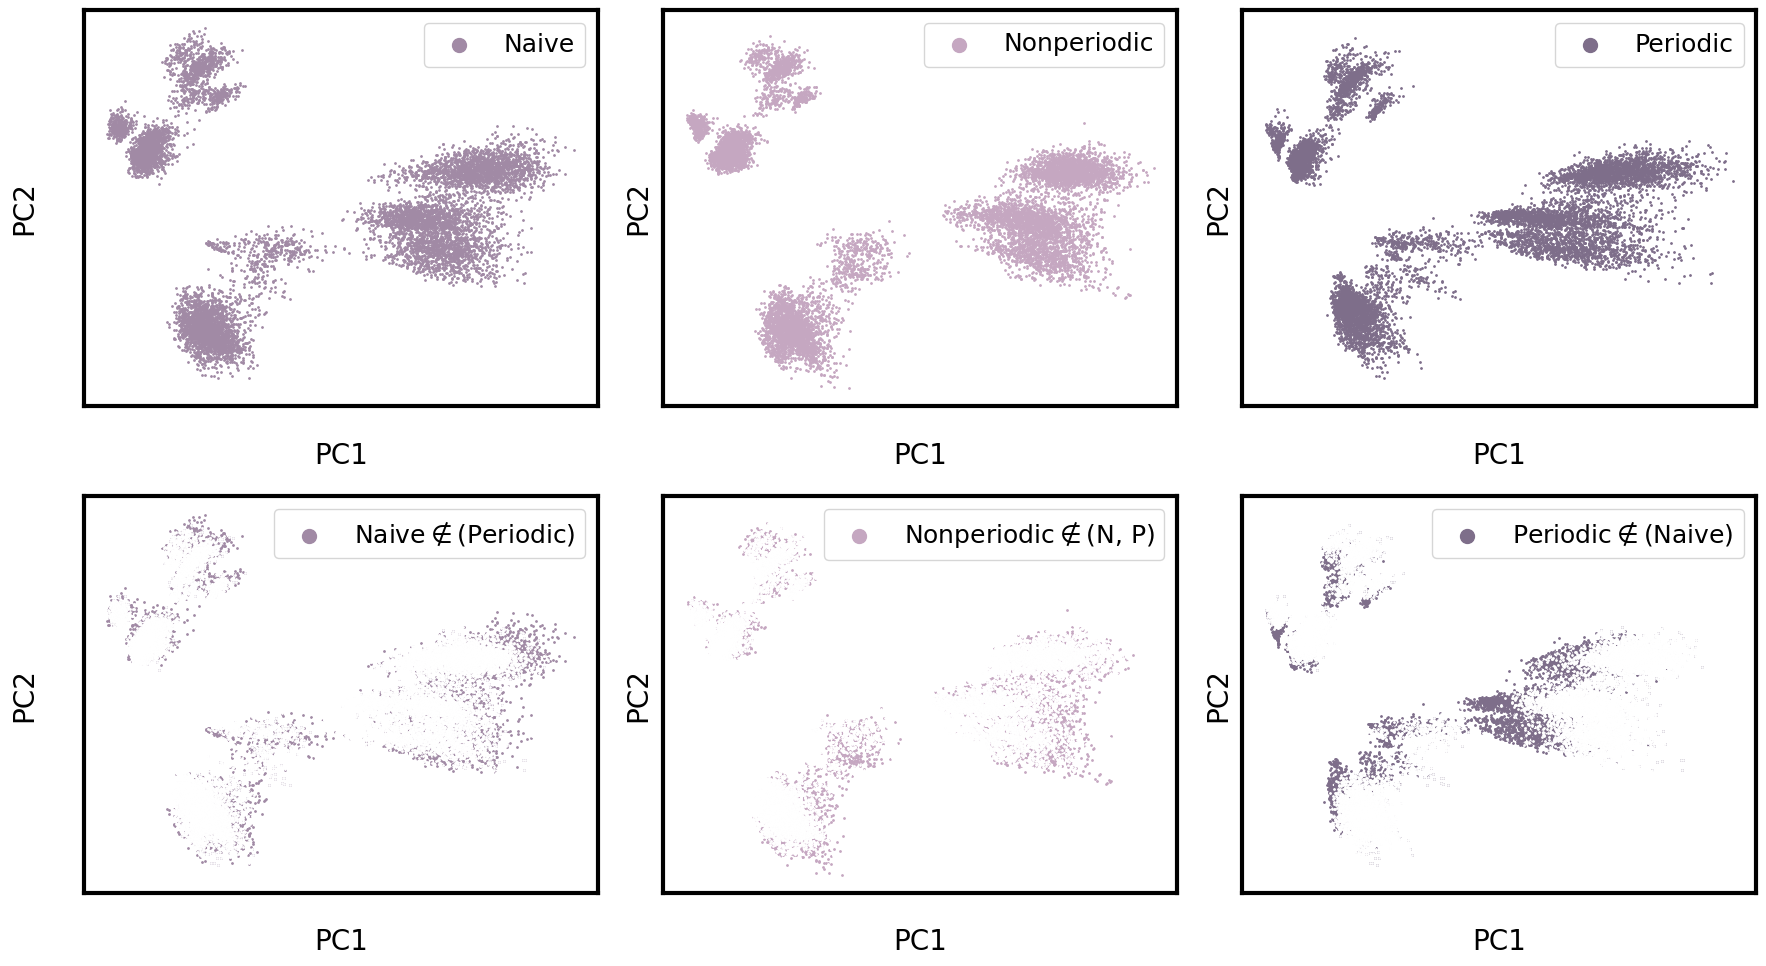

In [21]:
fig, ax = plt.subplots(2, 3, figsize = (18, 10), sharey=True,)
ax[0,1].scatter(X_np_pca[:, 0], X_np_pca[:, 1], s=1, alpha=1, color=colors[1], 
           label='Nonperiodic', rasterized=True)
ax[0,2].scatter(X_ft_pca[:, 0], X_ft_pca[:, 1], s=1, alpha=1, color=colors[3], 
           label='Periodic', rasterized=True)
ax[0,0].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color=colors[2], 
           label='Naive', rasterized=True)
ax[1,2].scatter(X_ft_pca[:, 0], X_ft_pca[:, 1], s=1, alpha=1, color=colors[3], 
           label=r'Periodic$\notin$(Naive)', rasterized=True)
ax[1,2].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color='white', rasterized=True)
ax[1,2].scatter(X_np_pca[:, 0], X_np_pca[:, 1], s=1, alpha=1, color='white', rasterized=True)

ax[1,0].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color=colors[2], 
           label=r'Naive$\notin$(Periodic)', rasterized=True)
ax[1,0].scatter(X_ft_pca[:, 0], X_ft_pca[:, 1], s=1, alpha=1, color='white', rasterized=True)
ax[1,0].scatter(X_np_pca[:, 0], X_np_pca[:, 1], s=1, alpha=1, color='white', rasterized=True)
ax[1,1].scatter(X_np_pca[:, 0], X_np_pca[:, 1], s=1, alpha=1, color=colors[1], 
           label=r'Nonperiodic$\notin$(N, P)', rasterized=True)
ax[1,1].scatter(X_ft_pca[:, 0], X_ft_pca[:, 1], s=1, alpha=1, color='white', rasterized=True)
ax[1,1].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color='white', rasterized=True)
for a in ax[1]:
    a.tick_params(axis='both', which='both', labelcolor=(0,0,0,0))
    a.tick_params(axis='both', which='both', color=(0,0,0,0))
for a in ax[0]:
    a.tick_params(axis='both', which='both', labelcolor=(0,0,0,0))
    a.tick_params(axis='both', which='both', color=(0,0,0,0))
ax[1,2].set_xlabel("PC1")
ax[1,2].set_ylabel("PC2")
ax[0,2].set_xlabel("PC1")
ax[0,2].set_ylabel("PC2")
ax[1,1].set_xlabel("PC1")
ax[1,1].set_ylabel("PC2")
ax[1,0].set_xlabel("PC1")
ax[1,0].set_ylabel("PC2")
ax[0,1].set_xlabel("PC1")
ax[0,1].set_ylabel("PC2")
ax[0,0].set_xlabel("PC1")
ax[0,0].set_ylabel("PC2")
ax[1,2].legend(markerscale=10)
ax[0,2].legend(markerscale=10)
ax[1,1].legend(markerscale=10)
ax[1,0].legend(markerscale=10)
ax[0,0].legend(markerscale=10)
ax[0,1].legend(markerscale=10)
fig.tight_layout()
fig.savefig("supplemental_figs/SI_PCA_Datasets_Nonperiodic.svg")


# PCA/Iterations


In [22]:
# Periodic
ft_set = read("../data/ChClCA_Finetuning/Periodic/Model:FT5/model/ft4_data.xyz", index=':')
ft3_set = read("../data/ChClCA_Finetuning/Periodic/Model:FT4/model/ft3_data.xyz", index=':')
ft2_set = read("../data/ChClCA_Finetuning/Periodic/Model:FT3/model/ft2_data.xyz", index=':')
ft1_set = read("../data/ChClCA_Finetuning/Periodic/Model:FT2/model/ft1_data.xyz", index=':')
u_set = read("../data/ChClCA_Finetuning/Periodic/Model:FT1/model/u_data.xyz", index=':')
ft4_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in ft_set]
ft3_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in ft3_set]
ft2_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in ft2_set]
ft1_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in ft1_set]
u_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in u_set]
X_ft4   = np.array(ft4_desc).reshape(-1, ft4_desc[0].shape[-1])
X_ft3   = np.array(ft3_desc).reshape(-1, ft3_desc[0].shape[-1])
X_ft2   = np.array(ft2_desc).reshape(-1, ft2_desc[0].shape[-1])
X_ft1   = np.array(ft1_desc).reshape(-1, ft1_desc[0].shape[-1])
X_u     = np.array(u_desc).reshape(-1, u_desc[0].shape[-1])
X_ft4_pca   = pca.transform(X_ft4)
X_ft3_pca   = pca.transform(X_ft3)
X_ft2_pca   = pca.transform(X_ft2)
X_ft1_pca   = pca.transform(X_ft1)
X_u_pca     = pca.transform(X_u)



In [23]:
# Naive
n50pt_set = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-50pts/ft_dataset_raw.xyz", index=':')
n40pt_set = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-40pts/40pt_dataset_raw.xyz", index=':')
n31pt_set = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-31pts/31pt_dataset_raw.xyz", index=':')
n21pt_set = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-21pts/21pt_dataset_raw.xyz", index=':')
n10pt_set = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-10pts/10pt_dataset_raw.xyz", index=':')
n10pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in n10pt_set]
n21pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in n21pt_set]
n31pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in n31pt_set]
n40pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in n40pt_set]
n50pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in n50pt_set]
X_n10pt = np.array(n10pt_desc).reshape(-1, n10pt_desc[0].shape[-1])
X_n21pt = np.array(n21pt_desc).reshape(-1, n21pt_desc[0].shape[-1])
X_n31pt = np.array(n31pt_desc).reshape(-1, n31pt_desc[0].shape[-1])
X_n40pt = np.array(n40pt_desc).reshape(-1, n40pt_desc[0].shape[-1])
X_n50pt = np.array(n50pt_desc).reshape(-1, n50pt_desc[0].shape[-1])
X_n50pt_pca = pca.transform(X_n50pt)
X_n40pt_pca = pca.transform(X_n40pt)
X_n21pt_pca = pca.transform(X_n21pt)
X_n31pt_pca = pca.transform(X_n31pt)
X_n10pt_pca = pca.transform(X_n10pt)

In [24]:
# Nonperiodic
np10pt_set = read("../data/ChClCA_Finetuning/Nonperiodic/Finetuned_Models/NP-10pts/np10pt_dataset_raw.xyz", index=':')
np21pt_set = read("../data/ChClCA_Finetuning/Nonperiodic/Finetuned_Models/NP-21pts/np21pt_dataset_raw.xyz", index=':')
np31pt_set = read("../data/ChClCA_Finetuning/Nonperiodic/Finetuned_Models/NP-31pts/np31pt_dataset_raw.xyz", index=':')
np40pt_set = read("../data/ChClCA_Finetuning/Nonperiodic/Finetuned_Models/NP-40pts/np40pt_dataset_raw.xyz", index=':')
np50pt_set = read("../data/ChClCA_Finetuning/Nonperiodic/Finetuned_Models/NP-50pts/np50pt_dataset_raw.xyz", index=':')
np10pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in np10pt_set]
np21pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in np21pt_set]
np31pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in np31pt_set]
np40pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in np40pt_set]
np50pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in np50pt_set]
X_np10pt = np.array(np10pt_desc).reshape(-1, np10pt_desc[0].shape[-1])
X_np21pt = np.array(np21pt_desc).reshape(-1, np21pt_desc[0].shape[-1])
X_np31pt = np.array(np31pt_desc).reshape(-1, np31pt_desc[0].shape[-1])
X_np40pt = np.array(np40pt_desc).reshape(-1, np40pt_desc[0].shape[-1])
X_np50pt = np.array(np50pt_desc).reshape(-1, np50pt_desc[0].shape[-1])
X_np50pt_pca   = pca.transform(X_np50pt)
X_np40pt_pca   = pca.transform(X_np40pt)
X_np31pt_pca   = pca.transform(X_np31pt)
X_np21pt_pca   = pca.transform(X_np21pt)
X_np10pt_pca   = pca.transform(X_np10pt)

/var/folders/b3/hx8307zs7kl5xs560yl1xw4m0000gn/T/ipykernel_1181/3935852142.py:94: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


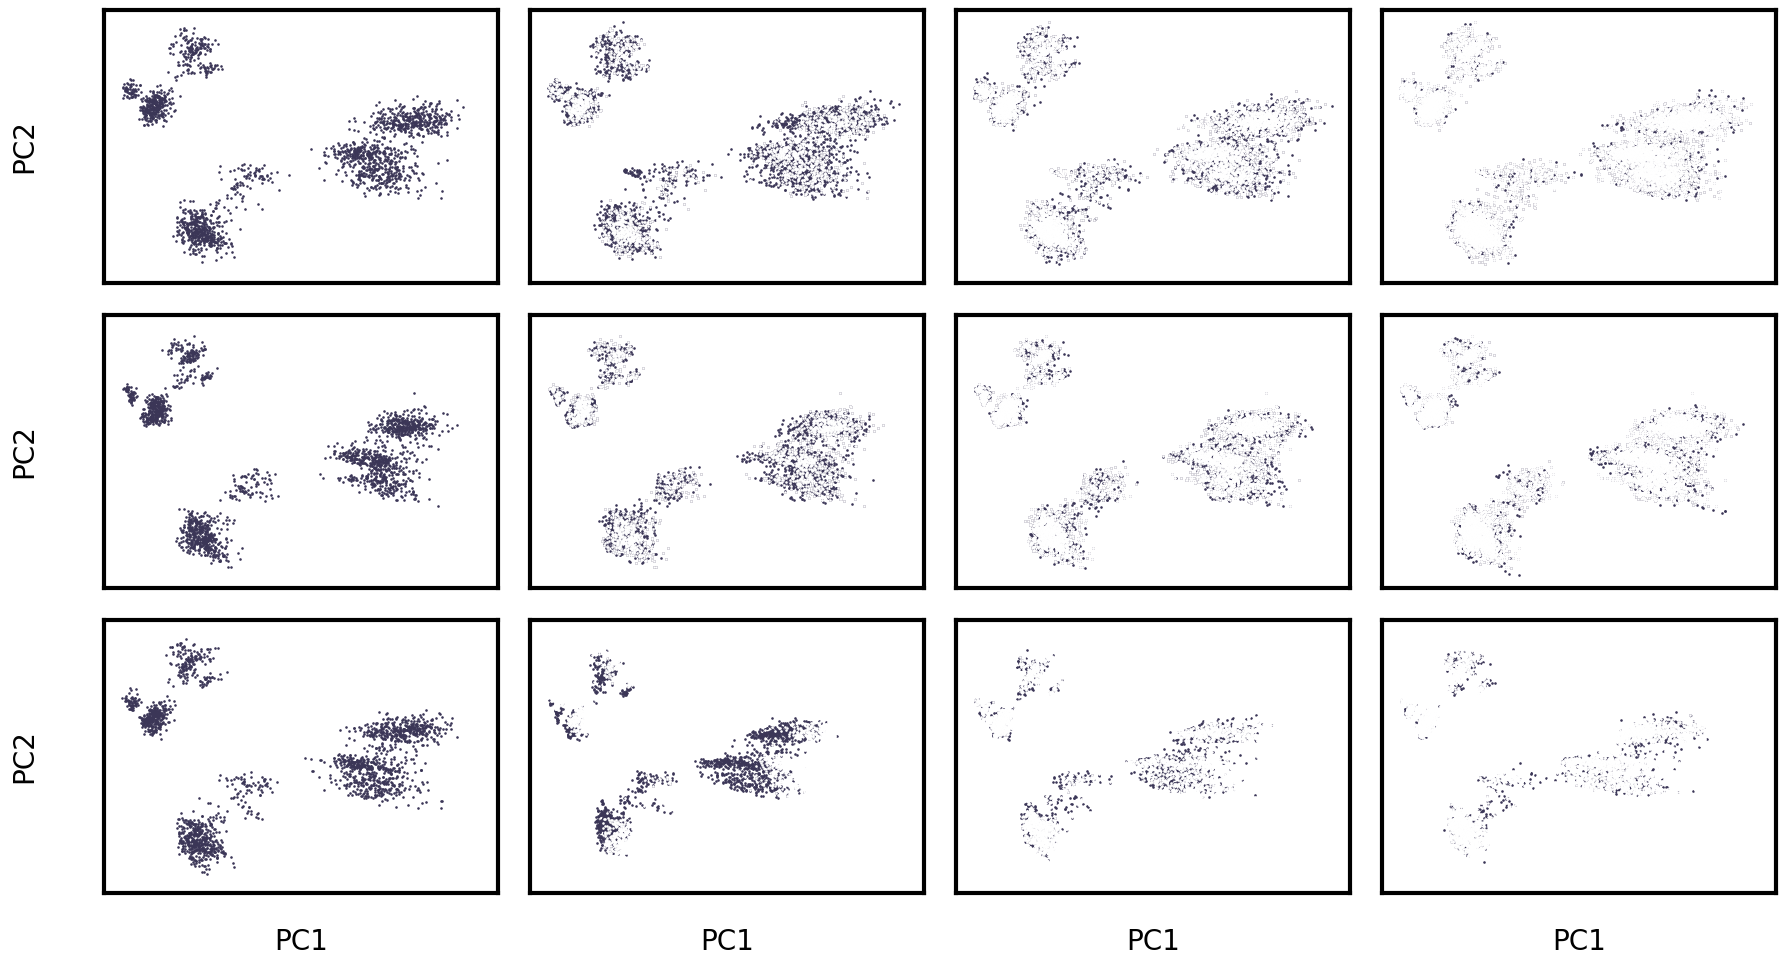

In [28]:
fig, axes = plt.subplots(3, 4, figsize=(18, 10), sharex=True, sharey=True)
for ax in axes[:, 1:].ravel():
    ax.set_ylabel("")
for ax in axes[:-1, :].ravel():
    ax.set_xlabel("")
for ax in axes[:,0]:
    ax.set_ylabel("PC2")

for ax in axes[-1,:]:
    ax.set_xlabel("PC1")
axes = axes.T
# N Panel 1
axes[0,0].scatter(X_n10pt_pca[:, 0], X_n10pt_pca[:, 1], 
                alpha=1, s=3, color=colors[5], label=r"N-10",marker='.',rasterized=False)
# N Panel 2
axes[1,0].scatter(X_n21pt_pca[:, 0], X_n21pt_pca[:, 1], 
                alpha=1, s=3, color=colors[5], label=r'N-21$\notin$(N-10)',marker='.',rasterized=False)
axes[1,0].scatter(X_n10pt_pca[:, 0], X_n10pt_pca[:, 1], 
                alpha=1, s=3, color='white',marker='.', edgecolor='white',rasterized=False)
# N Panel 3
axes[2,0].scatter(X_n31pt_pca[:, 0], X_n31pt_pca[:, 1], 
                alpha=1, s=3, color=colors[5], label=r'N-31$\notin$(N-21, N-10)',marker='.',rasterized=False)
axes[2,0].scatter(X_n21pt_pca[:, 0], X_n21pt_pca[:, 1], 
                alpha=1, s=3, color='white',marker='.', edgecolor='white',rasterized=False)
axes[2,0].scatter(X_n10pt_pca[:, 0], X_n10pt_pca[:, 1], 
                alpha=1, s=3, color='white',marker='.', edgecolor='white',rasterized=False)
# N Panel 4
axes[3,0].scatter(X_n40pt_pca[:, 0], X_n40pt_pca[:, 1], 
                alpha=1, s=3, color=colors[5], label=r'N-40$\notin$(N-31, N-21, N-10)',marker='.',rasterized=False)
axes[3,0].scatter(X_n31pt_pca[:, 0], X_n31pt_pca[:, 1], 
                alpha=1, s=3, color='white', edgecolor=None,marker='.',rasterized=False)
axes[3,0].scatter(X_n21pt_pca[:, 0], X_n21pt_pca[:, 1], 
                alpha=1, s=3, color='white', edgecolor=None,marker='.',rasterized=False)
axes[3,0].scatter(X_n10pt_pca[:, 0], X_n10pt_pca[:, 1], 
                alpha=1, s=3, color='white', edgecolor=None,marker='.',rasterized=False)

# Plot Nonperiodic
# NP Panel 1
axes[0,1].scatter(X_np10pt_pca[:, 0], X_np10pt_pca[:, 1], 
                alpha=1, s=3, color=colors[5], label=r'NP-10',marker='.',rasterized=False)
# NP Panel 2
axes[1,1].scatter(X_np21pt_pca[:, 0], X_np21pt_pca[:, 1], 
                alpha=1, s=3, color=colors[5], label=r'NP-21$\notin$(NP-10)',marker='.',rasterized=False)
axes[1,1].scatter(X_np10pt_pca[:, 0], X_np10pt_pca[:, 1], 
                alpha=1, s=3, color='white',marker='.',rasterized=False)
# NP Panel 3
axes[2,1].scatter(X_np31pt_pca[:, 0], X_np31pt_pca[:, 1], 
                alpha=1, s=3, color=colors[5], label=r'NP-31$\notin$(NP-21, NP-10)',marker='.',rasterized=False)
axes[2,1].scatter(X_np21pt_pca[:, 0], X_np21pt_pca[:, 1], 
                alpha=1, s=3, color='white',marker='.',rasterized=False)
axes[2,1].scatter(X_np10pt_pca[:, 0], X_np10pt_pca[:, 1], 
                alpha=1, s=3, color='white',marker='.',rasterized=False)
# NP Panel 4
axes[3,1].scatter(X_np40pt_pca[:, 0], X_np40pt_pca[:, 1], 
                alpha=1, s=3, color=colors[5], label=r'NP-40$\notin$(NP-31, NP-21, NP-10)',marker='.',rasterized=False)
axes[3,1].scatter(X_np31pt_pca[:, 0], X_np31pt_pca[:, 1], 
                alpha=1, s=3, color='white',marker='.',rasterized=False)
axes[3,1].scatter(X_np21pt_pca[:, 0], X_np21pt_pca[:, 1], 
                alpha=1, s=3, color='white',marker='.',rasterized=False)
axes[3,1].scatter(X_np10pt_pca[:, 0], X_np10pt_pca[:, 1], 
                alpha=1, s=3, color='white',marker='.',rasterized=False)

# Plot Periodic
# P Panel 1
axes[0,2].scatter(X_u_pca[:, 0], X_u_pca[:, 1], 
                alpha=1, s=3, color=colors[5], label=r'U',marker='.',rasterized=False)
# P Panel 2
axes[1,2].scatter(X_ft1_pca[:, 0], X_ft1_pca[:, 1], 
                alpha=1, s=3, color=colors[5], label=r'FT1$\notin$(U)', marker='.',rasterized=False)
axes[1,2].scatter(X_u_pca[:, 0], X_u_pca[:, 1], 
                alpha=1, s=3, color='white', marker='.',rasterized=False)
# P Panel 3
axes[2,2].scatter(X_ft2_pca[:, 0], X_ft2_pca[:, 1], 
                alpha=1, s=3, color=colors[5], label=r"FT2$\notin$(U, FT1)",marker='.',rasterized=False)
axes[2,2].scatter(X_ft1_pca[:, 0], X_ft1_pca[:, 1], 
                alpha=1, s=3, color='white',marker='.',rasterized=False)
axes[2,2].scatter(X_u_pca[:, 0], X_u_pca[:, 1], 
                alpha=1, s=3, color='white',marker='.',rasterized=False)
# P Panel 4
axes[3,2].scatter(X_ft3_pca[:, 0], X_ft3_pca[:, 1], 
                alpha=1, s=3, color=colors[5], label=r"FT3$\notin$(U, FT1, FT2)",marker='.',rasterized=False)
axes[3,2].scatter(X_ft2_pca[:, 0], X_ft2_pca[:, 1], 
                alpha=1, s=3, color='#FFFFFF', marker='.',rasterized=False)
axes[3,2].scatter(X_ft1_pca[:, 0], X_ft1_pca[:, 1], 
                alpha=1, s=3, color='#FFFFFF', marker='.',rasterized=False)
axes[3,2].scatter(X_u_pca[:, 0], X_u_pca[:, 1], 
                alpha=1, s=3, color='#FFFFFF', marker='.',rasterized=False)
for a in axes.flatten():
    a.tick_params(axis='both', which='both', labelcolor=(0,0,0,0))
    a.tick_params(axis='both', which='both', color=(0,0,0,0))

fig.tight_layout()
fig.savefig("figures/SI_PCA_per_iterationNonperiodic.svg")
fig.show()


# PCA for each trajectory vs. their respective dataset, Q values

## Naive trajectories & their respective datasets

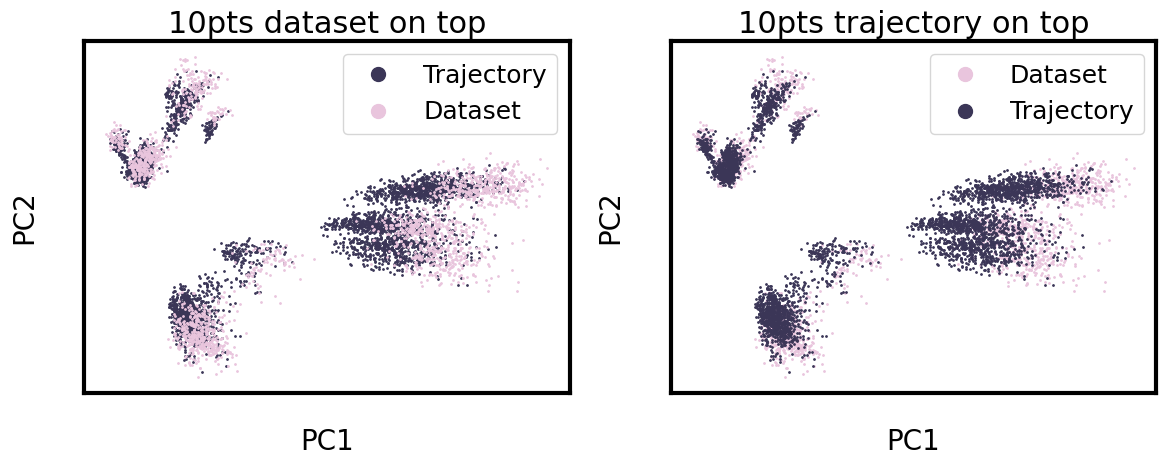

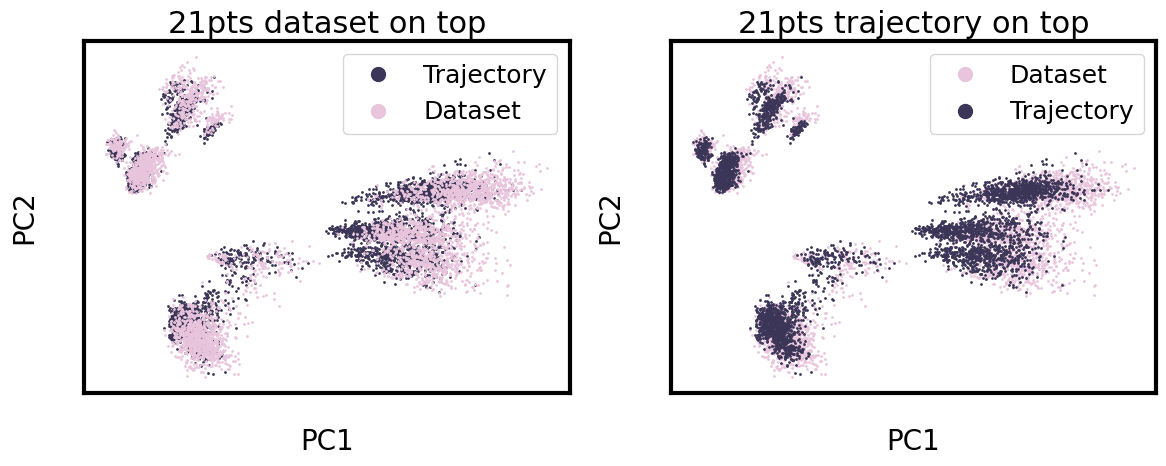

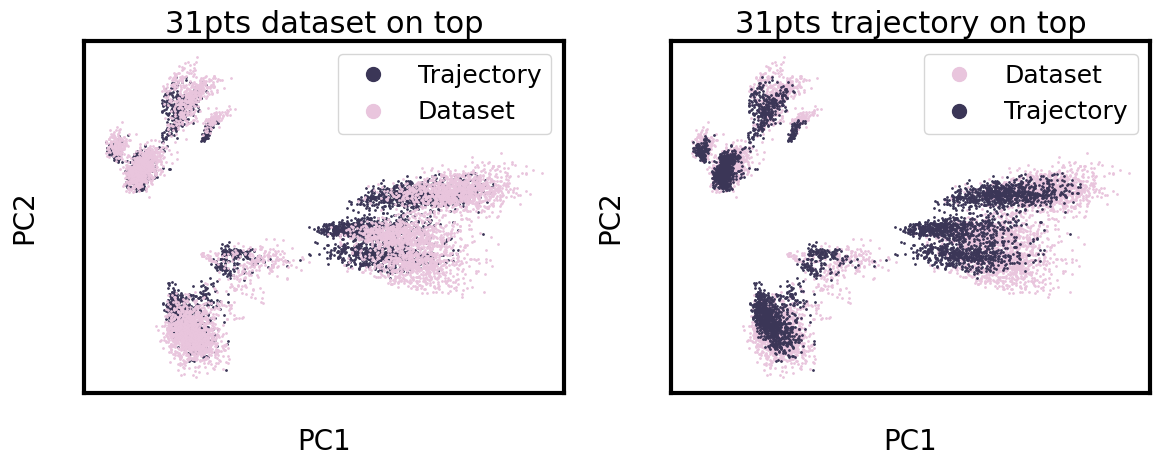

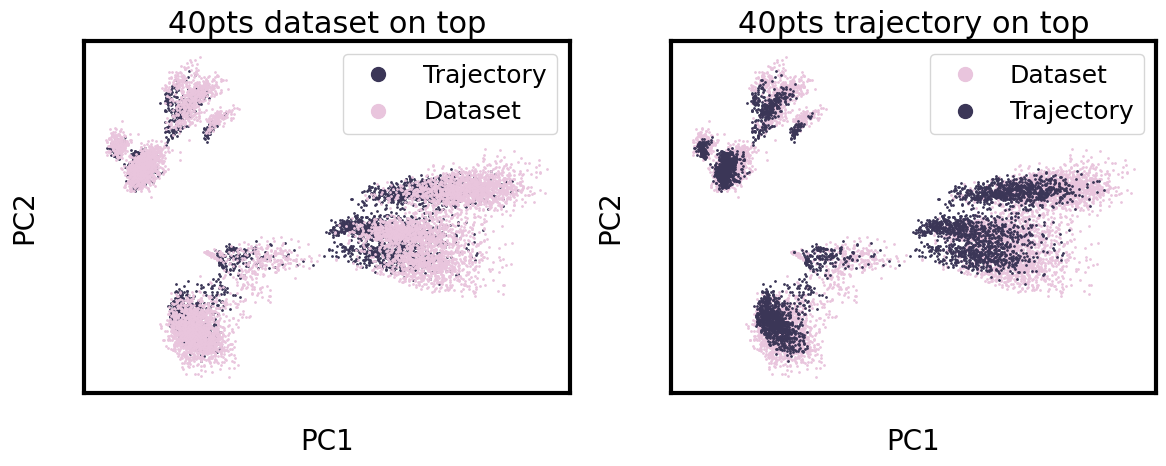

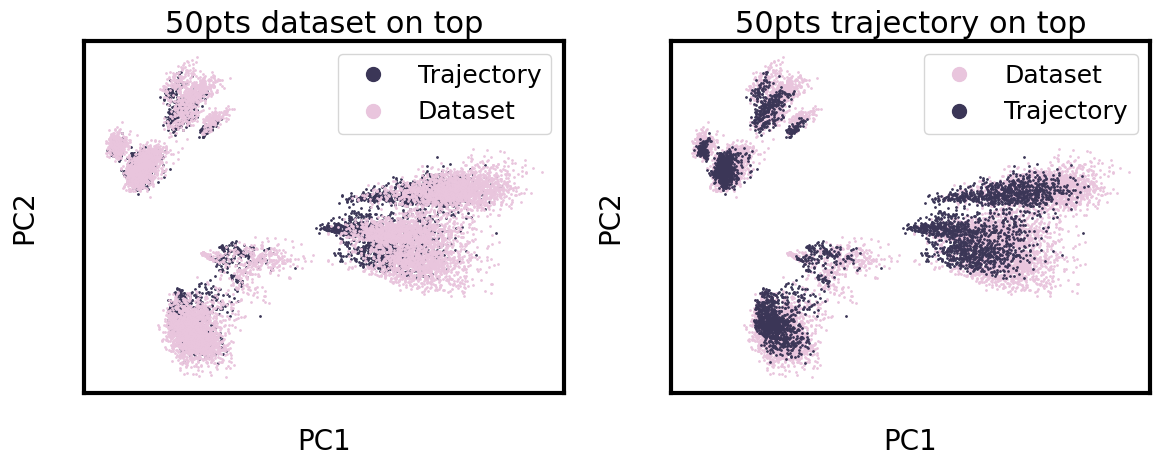

In [26]:
datasets_paths = {
    "10pts": "../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-10pts/10pt_dataset_raw.xyz",
    "21pts": "../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-21pts/21pt_dataset_raw.xyz",
    "31pts": "../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-31pts/31pt_dataset_raw.xyz",
    "40pts": "../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-40pts/40pt_dataset_raw.xyz",
    "50pts": "../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-50pts/ft_dataset_raw.xyz"
}

trajectories_paths = {
    "10pts": "../data/ChClCA_Evaluations/Naive/N-10pts/md/N-10pts_eval_ase.xyz",
    "21pts": "../data/ChClCA_Evaluations/Naive/N-21pts/md/N-21pts_eval_ase.xyz",
    "31pts": "../data/ChClCA_Evaluations/Naive/N-31pts/md/N-31pts_eval_ase.xyz",
    "40pts": "../data/ChClCA_Evaluations/Naive/N-40pts/md/N-40pts_eval_ase.xyz",
    "50pts": "../data/ChClCA_Evaluations/Naive/N-50pts/md/N-50pts_eval_ase.xyz"
}


# Loop over datasets
for key in datasets_paths:
    # Load datasets
    dataset = read(datasets_paths[key], index=":")
    trajectory = read(trajectories_paths[key], index="::100")
    
    # Collect species
    species = set()
    for atoms in dataset:
        species.update(atoms.get_chemical_symbols())
    species = list(species)
    
    # Initialize SOAP
    soap = SOAP(
        species=species,
        r_cut=5,
        n_max=8,
        l_max=6,
        sigma=0.375,
        periodic=True,
        sparse=False
    )
    
    # Generate SOAP descriptors
    dataset_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in dataset]
    traj_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in trajectory]
    
    # Flatten and convert to numpy
    X_dataset = np.array(dataset_desc).reshape(-1, dataset_desc[0].shape[-1])
    X_traj = np.array(traj_desc).reshape(-1, traj_desc[0].shape[-1])
    
    # PCA
    pca = PCA(n_components=5)
    X_dataset_pca = pca.fit_transform(X_dataset)
    X_traj_pca = pca.transform(X_traj)
    
    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
    ax[0].plot(X_traj_pca[:,0], X_traj_pca[:,1], 'o', color=colors[5], markersize=1, label='Trajectory', rasterized=True)
    ax[0].plot(X_dataset_pca[:,0], X_dataset_pca[:,1], 'o', color=colors[0], markersize=1, label='Dataset', rasterized=True)
    ax[0].set_title(f"{key} dataset on top")
    
    ax[1].plot(X_dataset_pca[:,0], X_dataset_pca[:,1], 'o', color=colors[0], markersize=1, label='Dataset', rasterized=True)
    ax[1].plot(X_traj_pca[:,0], X_traj_pca[:,1], 'o', color=colors[5], markersize=1, label='Trajectory', rasterized=True)
    ax[1].set_title(f"{key} trajectory on top")
    ax[0].set_xlabel("PC1")
    ax[0].set_ylabel("PC2")
    ax[1].set_xlabel("PC1")
    ax[1].set_ylabel("PC2")
    for a in ax:
        a.tick_params(axis='both', which='both', labelcolor=(0,0,0,0))
        a.tick_params(axis='both', which='both', color=(0,0,0,0))
    ax[0].legend(markerscale=10)
    ax[1].legend(markerscale=10)
    fig.tight_layout()
    fig.savefig(f"supplemental_figs/{key}_dataset_vs_trajectory.svg")
    
    plt.show()


## Periodic trajectories & their respective datasets

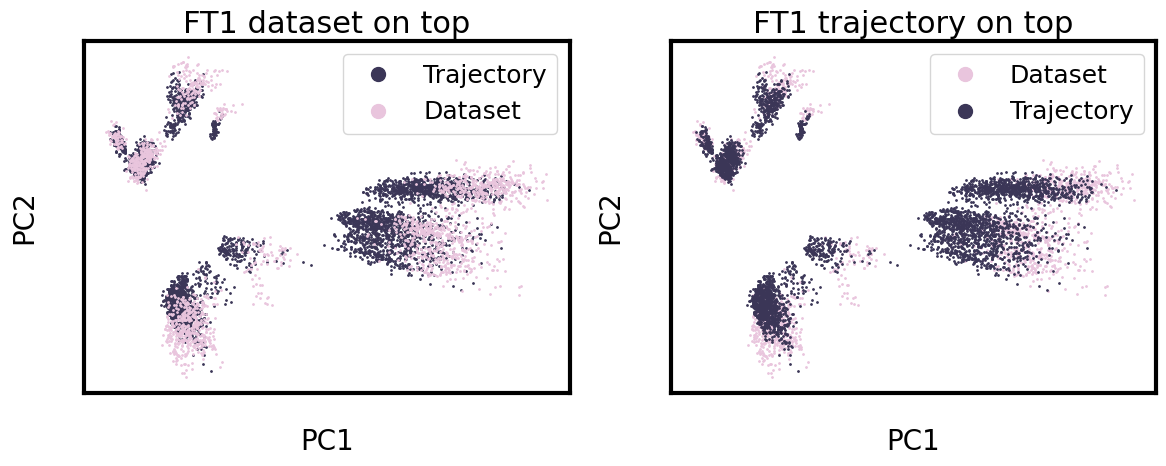

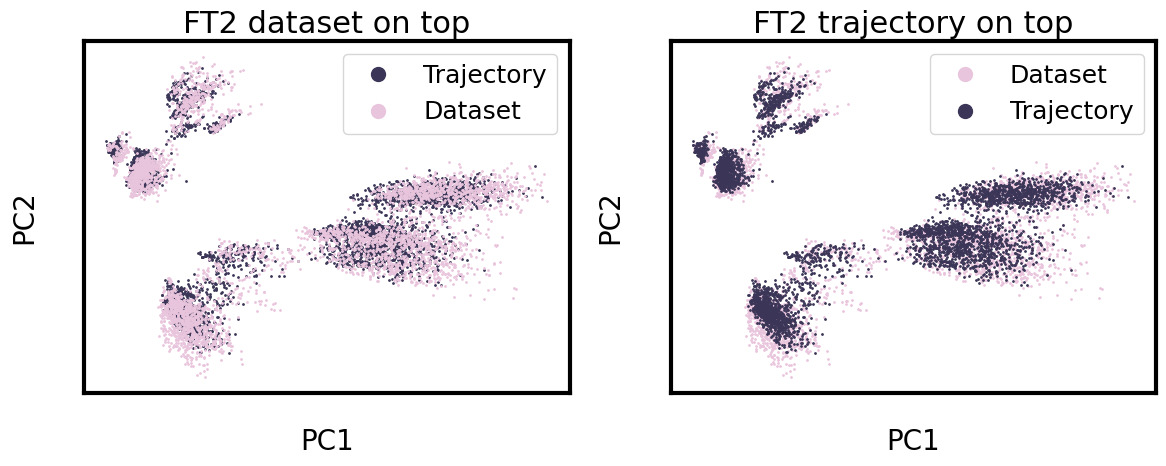

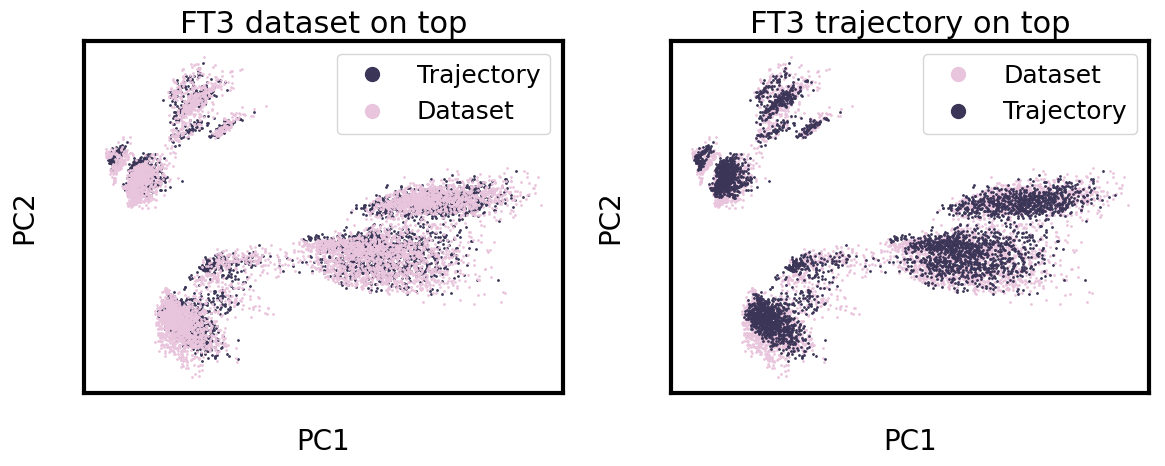

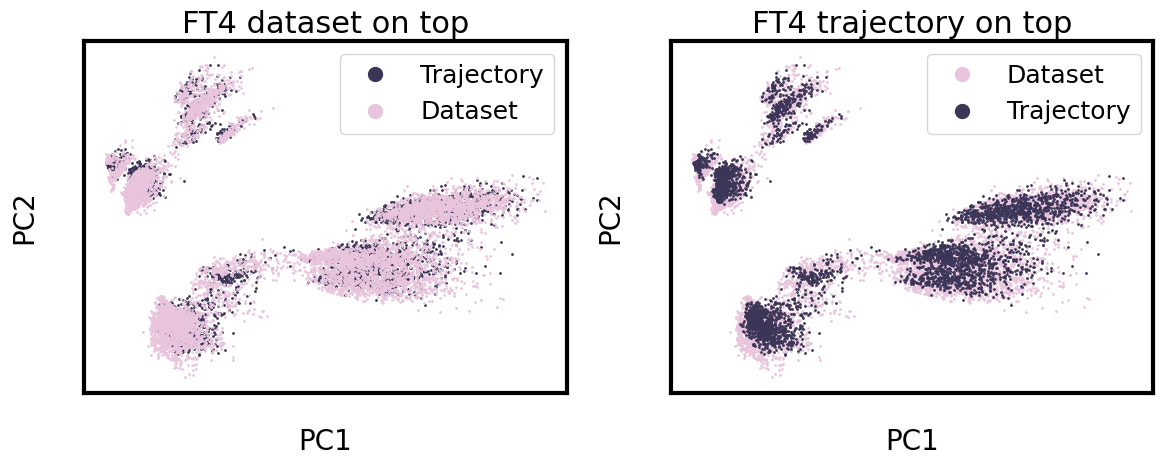

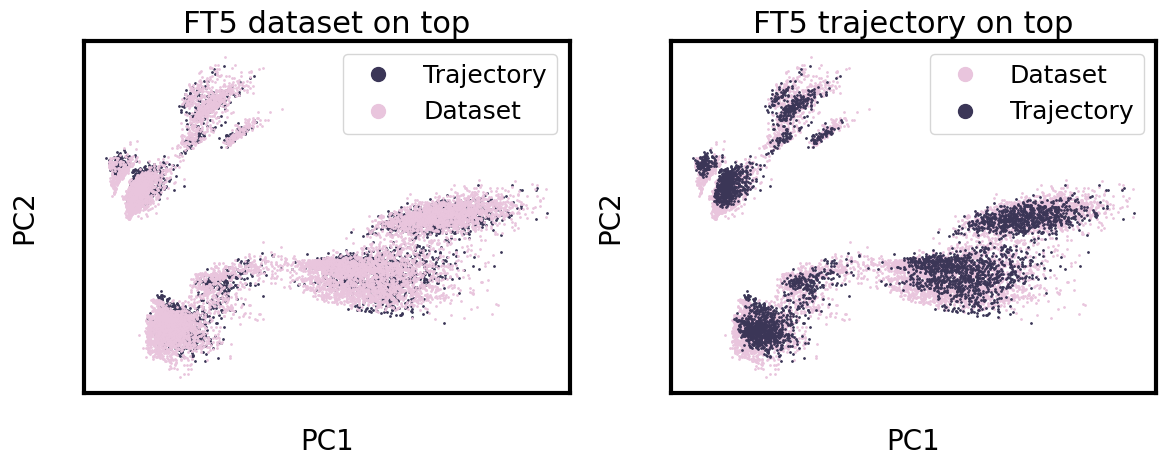

In [27]:
datasets_paths = {
    "FT1": "../data/ChClCA_Finetuning/Periodic/Model:FT1/model/u_data_raw.xyz",
    "FT2": "../data/ChClCA_Finetuning/Periodic/Model:FT2/model/ft1_data_raw.xyz",
    "FT3": "../data/ChClCA_Finetuning/Periodic/Model:FT3/model/ft2_data_raw.xyz",
    "FT4": "../data/ChClCA_Finetuning/Periodic/Model:FT4/model/ft3_data_raw.xyz",
    "FT5": "../data/ChClCA_Finetuning/Periodic/Model:FT5/model/ft4_data_raw.xyz"
}

trajectories_paths = {
    "FT1": "../data/ChClCA_Evaluations/Periodic/FT1/md/ft1_eval_ase.xyz",
    "FT2": "../data/ChClCA_Evaluations/Periodic/FT2/md/ft2_eval_ase.xyz",
    "FT3": "../data/ChClCA_Evaluations/Periodic/FT3/md/ft3_eval_ase.xyz",
    "FT4": "../data/ChClCA_Evaluations/Periodic/FT4/md/ft4_eval_ase.xyz",
    "FT5": "../data/ChClCA_Evaluations/Periodic/FT5/md/ft5_eval_ase.xyz"
}


# Loop over datasets
for key in datasets_paths:
    # Load datasets
    dataset = read(datasets_paths[key], index=":")
    trajectory = read(trajectories_paths[key], index="::100")
    
    # Collect species
    species = set()
    for atoms in dataset:
        species.update(atoms.get_chemical_symbols())
    species = list(species)
    
    # Initialize SOAP
    soap = SOAP(
        species=species,
        r_cut=5,
        n_max=8,
        l_max=6,
        sigma=0.375,
        periodic=True,
        sparse=False
    )
    
    # Generate SOAP descriptors
    dataset_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in dataset]
    traj_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in trajectory]
    
    # Flatten and convert to numpy
    X_dataset = np.array(dataset_desc).reshape(-1, dataset_desc[0].shape[-1])
    X_traj = np.array(traj_desc).reshape(-1, traj_desc[0].shape[-1])
    
    # PCA
    pca = PCA(n_components=5)
    X_dataset_pca = pca.fit_transform(X_dataset)
    X_traj_pca = pca.transform(X_traj)
    
    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
    ax[0].plot(X_traj_pca[:,0], X_traj_pca[:,1], 'o', color=colors[5], markersize=1, label='Trajectory', rasterized=True)
    ax[0].plot(X_dataset_pca[:,0], X_dataset_pca[:,1], 'o', color=colors[0], markersize=1, label='Dataset', rasterized=True)
    ax[0].set_title(f"{key} dataset on top")
    
    ax[1].plot(X_dataset_pca[:,0], X_dataset_pca[:,1], 'o', color=colors[0], markersize=1, label='Dataset', rasterized=True)
    ax[1].plot(X_traj_pca[:,0], X_traj_pca[:,1], 'o', color=colors[5], markersize=1, label='Trajectory', rasterized=True)
    ax[1].set_title(f"{key} trajectory on top")
    ax[0].set_xlabel("PC1")
    ax[0].set_ylabel("PC2")
    ax[1].set_xlabel("PC1")
    ax[1].set_ylabel("PC2")
    for a in ax:
        a.tick_params(axis='both', which='both', labelcolor=(0,0,0,0))
        a.tick_params(axis='both', which='both', color=(0,0,0,0))
    ax[0].legend(markerscale=10)
    ax[1].legend(markerscale=10)
    fig.tight_layout()
    fig.savefig(f"supplemental_figs/{key}_dataset_vs_trajectory.svg")
    
    plt.show()


In [ ]:
naive_set = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-50pts/ft_dataset_raw.xyz", index=':')
ft_set = read("../data/ChClCA_Finetuning/Periodic/Model:FT5/model/ft4_data_raw.xyz", index=':')
np_set = read("../data/ChClCA_Finetuning/Nonperiodic/Finetuned_Models/NP-50pts/np50pt_dataset_raw.xyz", index=':')
all_data = naive_set + ft_set + np_set
species = set()
for atoms in all_data:
    species.update(atoms.get_chemical_symbols())
species = list(species)
soap = SOAP(
    species=species,
    r_cut=5,
    n_max=8,
    l_max=6,
    sigma=0.375,
    periodic=True,
    sparse=False
)
# Generate SOAP
naive_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in naive_set]
ft_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in ft_set]
np_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in np_set]
# Convert to numpy arrays and flatten 
X_naive = np.array(naive_desc).reshape(-1, naive_desc[0].shape[-1])
X_ft = np.array(ft_desc).reshape(-1, ft_desc[0].shape[-1])
X_np = np.array(np_desc).reshape(-1, np_desc[0].shape[-1])

X_all = np.vstack([X_naive, X_ft, X_np])
# Fit PCA on combined data
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_all)
X_naive_pca = X_pca[:len(X_naive)]
X_ft_pca = X_pca[len(X_naive):len(X_naive)+len(X_ft)]
X_np_pca = X_pca[len(X_naive)+len(X_ft):]
explained_variance = pca.explained_variance_ratio_
print("Variance captured by each PC:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")

# Cumulative variance
cumulative_variance = explained_variance.cumsum()
print("\nCumulative variance:")
for i, cum_var in enumerate(cumulative_variance):
    print(f"PC1 to PC{i+1}: {cum_var:.4f} ({cum_var*100:.2f}%)")


In [ ]:
fig, ax = plt.subplots(2, 3, figsize = (18, 10), sharey=True,)
ax[0,1].scatter(X_np_pca[:, 0], X_np_pca[:, 1], s=1, alpha=1, color=colors[1], 
           label='Nonperiodic', rasterized=True)
ax[0,2].scatter(X_ft_pca[:, 0], X_ft_pca[:, 1], s=1, alpha=1, color=colors[3], 
           label='Periodic', rasterized=True)
ax[0,0].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color=colors[2], 
           label='Naive', rasterized=True)


ax[1,2].scatter(X_ft_pca[:, 0], X_ft_pca[:, 1], s=1, alpha=1, color=colors[3], 
           label=r'Periodic$\notin$(N, NP)', rasterized=True)
ax[1,2].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color='white', rasterized=True)
ax[1,2].scatter(X_np_pca[:, 0], X_np_pca[:, 1], s=1, alpha=1, color='white', rasterized=True)

ax[1,0].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color=colors[2], 
           label=r'Naive$\notin$(P, NP)', rasterized=True)
ax[1,0].scatter(X_ft_pca[:, 0], X_ft_pca[:, 1], s=1, alpha=1, color='white', rasterized=True)
ax[1,0].scatter(X_np_pca[:, 0], X_np_pca[:, 1], s=1, alpha=1, color='white', rasterized=True)
ax[1,1].scatter(X_np_pca[:, 0], X_np_pca[:, 1], s=1, alpha=1, color=colors[1], 
           label=r'Nonperiodic$\notin$(N, P)', rasterized=True)
ax[1,1].scatter(X_ft_pca[:, 0], X_ft_pca[:, 1], s=1, alpha=1, color='white', rasterized=True)
ax[1,1].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color='white', rasterized=True)
for a in ax[1]:
    # Make tick labels invisible but keep them in the layout
    a.tick_params(axis='both', which='both', labelcolor=(0,0,0,0))
    
    # Make tick marks invisible but still exist
    a.tick_params(axis='both', which='both', color=(0,0,0,0))
for a in ax[0]:
    # Make tick labels invisible but keep them in the layout
    a.tick_params(axis='both', which='both', labelcolor=(0,0,0,0))
    
    # Make tick marks invisible but still exist
    a.tick_params(axis='both', which='both', color=(0,0,0,0))
ax[1,2].set_xlabel("PC1")
ax[1,2].set_ylabel("PC2")
ax[0,2].set_xlabel("PC1")
ax[0,2].set_ylabel("PC2")
ax[1,1].set_xlabel("PC1")
ax[1,1].set_ylabel("PC2")
ax[1,0].set_xlabel("PC1")
ax[1,0].set_ylabel("PC2")
ax[0,1].set_xlabel("PC1")
ax[0,1].set_ylabel("PC2")
ax[0,0].set_xlabel("PC1")
ax[0,0].set_ylabel("PC2")
ax[1,2].legend(markerscale=10)
ax[0,2].legend(markerscale=10)
ax[1,1].legend(markerscale=10)
ax[1,0].legend(markerscale=10)
ax[0,0].legend(markerscale=10)
ax[0,1].legend(markerscale=10)
fig.tight_layout()
fig.savefig("figures/SI_PCA_DatasetsNonperiodic.svg")


In [ ]:
np10pt_set = read("../data/ChClCA_Finetuning/Nonperiodic/Finetuned_Models/NP-10pts/np10pt_dataset_raw.xyz", index=':')
np21pt_set = read("../data/ChClCA_Finetuning/Nonperiodic/Finetuned_Models/NP-21pts/np21pt_dataset_raw.xyz", index=':')
np31pt_set = read("../data/ChClCA_Finetuning/Nonperiodic/Finetuned_Models/NP-31pts/np31pt_dataset_raw.xyz", index=':')
np40pt_set = read("../data/ChClCA_Finetuning/Nonperiodic/Finetuned_Models/NP-40pts/np40pt_dataset_raw.xyz", index=':')
np50pt_set = read("../data/ChClCA_Finetuning/Nonperiodic/Finetuned_Models/NP-50pts/np50pt_dataset_raw.xyz", index=':')
all_naive_data = np10pt_set + np21pt_set + np31pt_set + np40pt_set + np50pt_set
species = set()
for atoms in np50pt_set:
    species.update(atoms.get_chemical_symbols())
species = list(species)

In [ ]:
# Generate SOAP
np10pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in np10pt_set]
np21pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in np21pt_set]
np31pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in np31pt_set]
np40pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in np40pt_set]
np50pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in np50pt_set]
# np50pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in np50pt_set]
# Convert to numpy arrays and flatten
X_np10pt = np.array(np10pt_desc).reshape(-1, np10pt_desc[0].shape[-1])
X_np21pt = np.array(np21pt_desc).reshape(-1, np21pt_desc[0].shape[-1])
X_np31pt = np.array(np31pt_desc).reshape(-1, np31pt_desc[0].shape[-1])
X_np40pt = np.array(np40pt_desc).reshape(-1, np40pt_desc[0].shape[-1])
X_np50pt = np.array(np50pt_desc).reshape(-1, np50pt_desc[0].shape[-1])
# X_np50pt = np.array(np50pt_desc).reshape(-1, np50pt_desc[0].shape[-1])
X_np50pt_pca   = pca.transform(X_np50pt)
X_np40pt_pca   = pca.transform(X_np40pt)
X_np31pt_pca   = pca.transform(X_np31pt)
X_np21pt_pca   = pca.transform(X_np21pt)
X_np10pt_pca   = pca.transform(X_np10pt)



In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()
# ---- Plot 1 ----
axes[0].scatter(X_np10pt_pca[:, 0], X_np10pt_pca[:, 1], 
                alpha=1, s=3, color=colors[5], label=r'NP-10',marker='.',rasterized=False)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
# axes[0].set_title("U->FT1")

# ---- Plot 2 ----
axes[1].scatter(X_np21pt_pca[:, 0], X_np21pt_pca[:, 1], 
                alpha=1, s=3, color=colors[5], label=r'NP-21$\notin$(NP-10)',marker='.',rasterized=False)
axes[1].scatter(X_np10pt_pca[:, 0], X_np10pt_pca[:, 1], 
                alpha=1, s=3, color='white',marker='.',rasterized=False)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
# axes[1].set_title("FT1->FT2")

# ---- Plot 3 ----
axes[2].scatter(X_np31pt_pca[:, 0], X_np31pt_pca[:, 1], 
                alpha=1, s=3, color=colors[5], label=r'NP-31$\notin$(NP-21, NP-10)',marker='.',rasterized=False)
axes[2].scatter(X_np21pt_pca[:, 0], X_np21pt_pca[:, 1], 
                alpha=1, s=3, color='white',marker='.',rasterized=False)
axes[2].scatter(X_np10pt_pca[:, 0], X_np10pt_pca[:, 1], 
                alpha=1, s=3, color='white',marker='.',rasterized=False)
axes[2].set_xlabel("PC1")
axes[2].set_ylabel("PC2")
# axes[2].set_title("FT2->FT3")

# ---- Plot 4 ----

axes[3].scatter(X_np40pt_pca[:, 0], X_np40pt_pca[:, 1], 
                alpha=1, s=3, color=colors[5], label=r'NP-40$\notin$(NP-31, NP-21, NP-10)',marker='.',rasterized=False)
axes[3].scatter(X_np31pt_pca[:, 0], X_np31pt_pca[:, 1], 
                alpha=1, s=3, color='white',marker='.',rasterized=False)
axes[3].scatter(X_np21pt_pca[:, 0], X_np21pt_pca[:, 1], 
                alpha=1, s=3, color='white',marker='.',rasterized=False)
axes[3].scatter(X_np10pt_pca[:, 0], X_np10pt_pca[:, 1], 
                alpha=1, s=3, color='white',marker='.',rasterized=False)
axes[3].set_xlabel("PC1")
axes[3].set_ylabel("PC2")

# axes[3].set_title("FT3->FT4")
axes[0].legend(markerscale=5)
axes[1].legend(markerscale=5)
axes[2].legend(markerscale=5, prop={'size': 17})
axes[3].legend(markerscale=5, prop={'size': 16})
for a in axes:
    # Make tick labels invisible but keep them in the layout
    a.tick_params(axis='both', which='both', labelcolor=(0,0,0,0))
    
    # Make tick marks invisible but still exist
    a.tick_params(axis='both', which='both', color=(0,0,0,0))
fig.tight_layout()
fig.savefig("figures/results_nonperiodicPCA_per_iteration.svg")
fig.show()


# LiCl Analysis

## Periodic Training

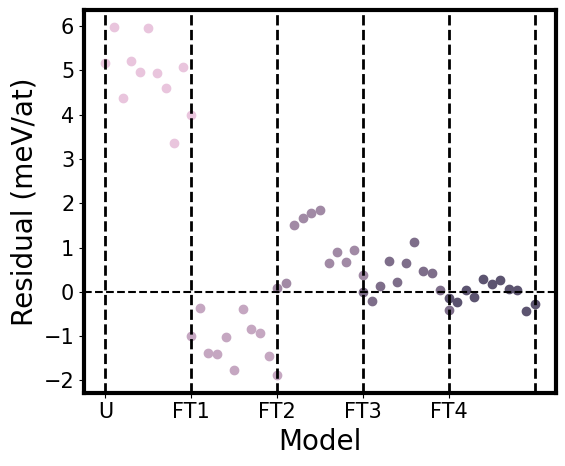

In [321]:
U_Train_DFT =  get_DFT_from_directory("../data/LiClCoCl2_Finetuning/Periodic/U/dft")
FT1_Train_DFT =  get_DFT_from_directory("../data/LiClCoCl2_Finetuning/Periodic/FT1/dft")
FT2_Train_DFT =  get_DFT_from_directory("../data/LiClCoCl2_Finetuning/Periodic/FT2/dft")
FT3_Train_DFT =  get_DFT_from_directory("../data/LiClCoCl2_Finetuning/Periodic/FT3/dft")
FT4_Train_DFT =  get_DFT_from_directory("../data/LiClCoCl2_Finetuning/Periodic/FT4/dft")
U_Train_MD   = pd.read_csv("../data/LiClCoCl2_Finetuning/Periodic/U/md/run_info.txt", sep='\t')
FT1_Train_MD = pd.read_csv("../data/LiClCoCl2_Finetuning/Periodic/FT1/md/run_info.txt", sep='\t')
FT2_Train_MD = pd.read_csv("../data/LiClCoCl2_Finetuning/Periodic/FT2/md/run_info.txt", sep='\t')
FT3_Train_MD = pd.read_csv("../data/LiClCoCl2_Finetuning/Periodic/FT3/md/run_info.txt", sep='\t')
FT4_Train_MD = pd.read_csv("../data/LiClCoCl2_Finetuning/Periodic/FT4/md/run_info.txt", sep='\t')
training_DFT = [U_Train_DFT, FT1_Train_DFT, FT2_Train_DFT, FT3_Train_DFT, FT4_Train_DFT]
training_MD = [U_Train_MD, FT1_Train_MD, FT2_Train_MD, FT3_Train_MD, FT4_Train_MD]
fig, ax = plt.subplots(figsize = (6, 5))
for idx, trajectory in enumerate(zip(training_DFT, training_MD)):
    diffs = {}
    for timestep in trajectory[0].keys():
        diff = (trajectory[1].iloc[timestep]['PotEng'] - trajectory[0][timestep].energy) * 1000 / 170
        diffs[timestep/1000+idx] = diff
    ax.plot(diffs.keys(), diffs.values(), 'o', color = colors[idx])
ax.axhline(y=0, linestyle='--', color='black')
ax.axvline(x=1, linestyle='--', linewidth=2, color='black')
# ranges = [(1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7)]
# for (start, end), color in zip(ranges, colors):
#     ax.axvspan(start, end, alpha=0.3, color=color)
ax.axvline(x=2, linestyle='--', linewidth=2, color='black')
ax.axvline(x=3, linestyle='--', linewidth=2, color='black')
ax.axvline(x=4, linestyle='--', linewidth=2, color='black')
ax.axvline(x=5, linestyle='--', linewidth=2, color='black')
ax.axvline(x=6, linestyle='--', linewidth=2, color='black')
ax.set_xticks(np.arange(1,6), ['U', 'FT1', 'FT2', 'FT3', 'FT4'])
ax.set_xlabel("Model")
ax.set_ylabel("Residual (meV/at)")
fig.tight_layout()

# Evaluations

In [322]:
U_Test_DFT =  get_DFT_from_directory("../data/LiClCoCl2_Evaluations/U/dft")
FT1_Test_DFT = get_DFT_from_directory("../data/LiClCoCl2_Evaluations/Periodic/FT1/dft")
FT2_Test_DFT = get_DFT_from_directory("../data/LiClCoCl2_Evaluations/Periodic/FT2/dft")
FT3_Test_DFT = get_DFT_from_directory("../data/LiClCoCl2_Evaluations/Periodic/FT3/dft")
FT4_Test_DFT = get_DFT_from_directory("../data/LiClCoCl2_Evaluations/Periodic/FT4/dft")
U_Test_MD   =  pd.read_csv("../data/LiClCoCl2_Evaluations/U/md/run_info.txt", sep='\t')
FT1_Test_MD = pd.read_csv("../data/LiClCoCl2_Evaluations/Periodic/FT1/md/run_info.txt", sep='\t')
FT2_Test_MD = pd.read_csv("../data/LiClCoCl2_Evaluations/Periodic/FT2/md/run_info.txt", sep='\t')
FT3_Test_MD = pd.read_csv("../data/LiClCoCl2_Evaluations/Periodic/FT3/md/run_info.txt", sep='\t')
FT4_Test_MD = pd.read_csv("../data/LiClCoCl2_Evaluations/Periodic/FT4/md/run_info.txt", sep='\t')

N11pts_Test_DFT = get_DFT_from_directory("../data/LiClCoCl2_Evaluations/Naive/N-11pts/dft")
N22pts_Test_DFT = get_DFT_from_directory("../data/LiClCoCl2_Evaluations/Naive/N-22pts/dft")
N33pts_Test_DFT = get_DFT_from_directory("../data/LiClCoCl2_Evaluations/Naive/N-33pts/dft")
N44pts_Test_DFT = get_DFT_from_directory("../data/LiClCoCl2_Evaluations/Naive/N-44pts/dft")
N11pts_Test_MD = pd.read_csv("../data/LiClCoCl2_Evaluations/Naive/N-11pts/md/run_info.txt", sep='\t')
N22pts_Test_MD = pd.read_csv("../data/LiClCoCl2_Evaluations/Naive/N-22pts/md/run_info.txt", sep='\t')
N33pts_Test_MD = pd.read_csv("../data/LiClCoCl2_Evaluations/Naive/N-33pts/md/run_info.txt", sep='\t')
N44pts_Test_MD = pd.read_csv("../data/LiClCoCl2_Evaluations/Naive/N-44pts/md/run_info.txt", sep='\t')
periodic_test_DFT = [U_Test_DFT, FT1_Test_DFT, FT2_Test_DFT, FT3_Test_DFT, FT4_Test_DFT]
periodic_test_MD = [U_Test_MD, FT1_Test_MD, FT2_Test_MD, FT3_Test_MD, FT4_Test_MD]
naive_test_DFT = [U_Test_DFT, N11pts_Test_DFT, N22pts_Test_DFT, N33pts_Test_DFT, N44pts_Test_DFT]
naive_test_MD = [U_Test_MD, N11pts_Test_MD, N22pts_Test_MD, N33pts_Test_MD, N44pts_Test_MD]

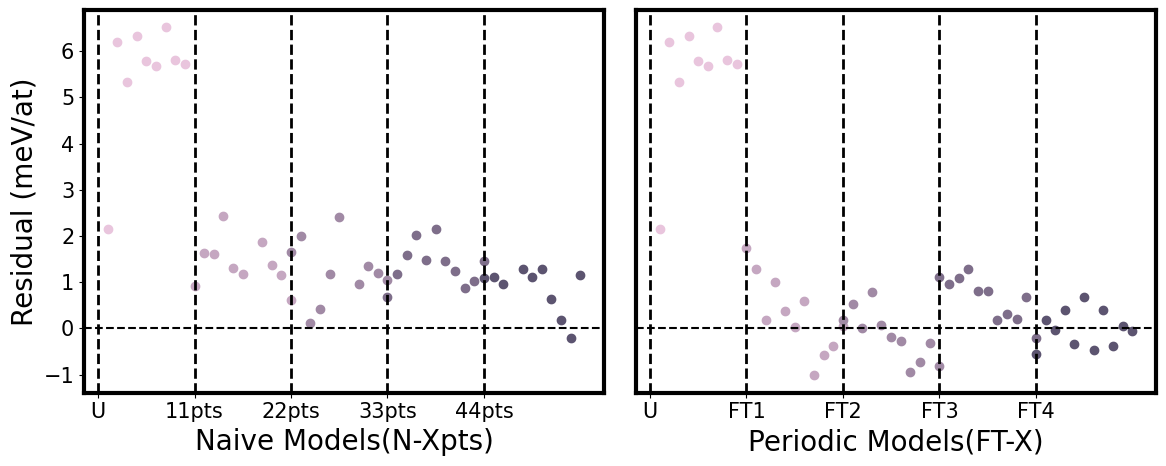

In [323]:
fig, ax = plt.subplots(1, 2, figsize = (12, 5), sharey=True)
# Left plot, Naive
for idx, trajectory in enumerate(zip(naive_test_DFT, naive_test_MD)):
    diffs = {}
    for timestep in trajectory[0].keys():
        diff = (trajectory[1].iloc[timestep]['PotEng'] - trajectory[0][timestep].energy) * 1000 / 170
        diffs[timestep/1000+idx] = diff
    ax[0].plot(diffs.keys(), diffs.values(), 'o', color = colors[idx])
# Right plot, Periodic
for idx, trajectory in enumerate(zip(periodic_test_DFT, periodic_test_MD)):
    diffs = {}
    for timestep in trajectory[0].keys():
        diff = (trajectory[1].iloc[timestep]['PotEng'] - trajectory[0][timestep].energy) * 1000 / 170
        diffs[timestep/1000+idx] = diff
    ax[1].plot(diffs.keys(), diffs.values(), 'o', color = colors[idx])
ax[1].set_xticks(np.arange(1,6), ['U', 'FT1', 'FT2', 'FT3', 'FT4'])
ax[0].set_xticks(np.arange(1,6), ['U', '11pts', '22pts', '33pts', '44pts'])
ax[0].axhline(y=0, linestyle='--', color='black')
ax[1].axhline(y=0, linestyle='--', color='black')
ax[0].axvline(x=1, linestyle='--', linewidth=2, color='black')
ax[0].axvline(x=2, linestyle='--', linewidth=2, color='black')
ax[0].axvline(x=3, linestyle='--', linewidth=2, color='black')
ax[0].axvline(x=4, linestyle='--', linewidth=2, color='black')
ax[0].axvline(x=5, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=1, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=2, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=3, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=4, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=5, linestyle='--', linewidth=2, color='black')
ax[1].tick_params(axis='y', which='both', labelcolor=(0,0,0,0))
ax[1].tick_params(axis='y', which='both', color=(0,0,0,0))
ax[0].set_xlabel("Naive Models(N-Xpts)")
ax[1].set_xlabel("Periodic Models(FT-X)")
ax[0].set_ylabel("Residual (meV/at)")
fig.tight_layout()
fig.savefig('./supplemental_figs/DiluteLiClCoCl2.svg')